In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import RegularGridInterpolator

from clim_functions import day_plot


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
fp = '/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_tracked.pkl'
df_tracked = pd.read_pickle(fp)
df_tracked['q11'] = [Q[0,0] for Q in df_tracked.Q]
df_tracked['q12'] = [Q[1,0] for Q in df_tracked.Q]
df_tracked['q22'] = [Q[1,1] for Q in df_tracked.Q]

df_tracked


,Day,fnumber,nxc,nyc,Cyc,xc,yc,w,Q,Omega0,...,Rc,psi0,R,AR,eddy_idx,Eddy,next_num,q11,q12,q22
0,1462,1461,830.0,1515.0,AE,829.866281,1515.784745,0.000015,"[[0.6818813511835662, -0.01769448655641243], [...",0.006939,...,97.033130,-38.436614,43.683507,1.467389,0,0,67099,0.681881,-0.017694,1.466990
1,1462,1461,358.0,1408.0,AE,357.716018,1407.297048,0.000029,"[[1.172910762121831, -0.5171323359074603], [-0...",0.012814,...,87.972813,-41.501314,59.972382,1.645935,1,1,67099,1.172911,-0.517132,1.080582
2,1462,1461,928.0,1356.0,CE,929.039452,1356.121406,-0.000010,"[[0.6394227429140328, -0.36905411384618786], [...",-0.004169,...,113.963003,42.344780,74.600410,1.886162,2,2,67099,0.639423,-0.369054,1.776917
3,1462,1461,506.0,1354.0,CE,505.545197,1353.764885,-0.000030,"[[1.0195167656782433, -0.20828542587929186], [...",-0.014654,...,104.868137,68.634490,62.850374,1.229757,3,3,67099,1.019517,-0.208285,1.023409
4,1462,1461,754.0,1285.0,AE,754.096128,1284.807711,0.000021,"[[1.1420914556654878, -0.3819244877484292], [-...",0.009650,...,104.502082,-42.648453,64.676066,1.460876,4,4,67099,1.142091,-0.381924,1.003305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280853,10650,10641,860.0,180.0,CE,859.194829,180.306373,-0.000007,"[[0.6614053902780358, 0.4389834439185585], [0....",-0.003002,...,82.764188,10.994798,59.843014,1.952544,16,67042,67099,0.661405,0.438983,1.803291
280854,10650,10641,349.0,158.0,AE,348.639821,156.731941,0.000030,"[[1.4645774777137426, -0.1681457560425603], [-...",0.013843,...,118.891449,-77.470619,43.106056,1.500011,17,67082,67099,1.464577,-0.168146,0.702095
280855,10650,10641,973.0,126.0,CE,981.263303,128.903719,-0.000003,"[[0.3331432297976212, 0.22917891709183946], [0...",-0.000959,...,55.056225,2.299476,24.775338,3.177834,18,67083,67099,0.333143,0.229179,3.159371
280856,10650,10641,805.0,95.0,AE,805.224646,95.090287,0.000010,"[[1.458787846536923, 0.38837617534635543], [0....",0.004449,...,61.560240,-10.280739,45.893871,1.636702,19,67038,67099,1.458788,0.388376,0.788899


In [4]:
# Clean
df_eddies = df_tracked[['Eddy', 'Day', 'Cyc', 'xc', 'yc', 'w', 'Omega', 'q11', 'q12', 'q22', 'Rc', 'psi0', 'AR', 'R']].copy().sort_values(by=['Eddy', 'Day'])
df_eddies = df_eddies.groupby('Eddy').filter(lambda g: g['Day'].max() - g['Day'].min() >= 21) # Keep only mesoscale - older than 3 weeks
df_eddies['Eddy'] = df_eddies['Eddy'].rank(method='dense').astype(int) # Relabel the Eddy's 1,2,3..
df_eddies = df_eddies.reset_index(drop=True)

# Find Lon and Lat values
xg, yg = x_grid, y_grid
lon_interp = RegularGridInterpolator((yg, xg), lon_rho.T, bounds_error=False, fill_value=np.nan)
lat_interp = RegularGridInterpolator((yg, xg), lat_rho.T, bounds_error=False, fill_value=np.nan)
points = np.column_stack((df_eddies['yc'].to_numpy(), df_eddies['xc'].to_numpy()))
df_eddies['lon'] = lon_interp(points)
df_eddies['lat'] = lat_interp(points)
# Re order columns
cols = df_eddies.columns.tolist()
i = cols.index('Cyc') + 1
base = [c for c in cols if c not in ('lon','lat')]
new_order = base[:i] + ['lon','lat'] + base[i:]
df_eddies = df_eddies[new_order].reset_index(drop=True)
df_eddies

df_eddies


,Eddy,Day,Cyc,lon,lat,xc,yc,w,Omega,q11,q12,q22,Rc,psi0,AR,R
0,1,1462,CE,161.080543,-29.738791,929.039452,1356.121406,-0.000010,-0.006521,0.639423,-0.369054,1.776917,113.963003,42.344780,1.886162,74.600410
1,1,1463,CE,160.822254,-29.758790,905.631783,1345.345472,-0.000016,-0.007592,1.381800,-0.265871,0.774850,120.222494,54.862382,1.481790,68.591110
2,1,1464,CE,160.892031,-29.759089,912.125510,1347.651173,-0.000011,-0.006902,1.166486,-0.052011,0.859594,143.572687,71.135506,1.175061,79.541960
3,1,1465,CE,160.929408,-29.613181,911.183953,1364.374448,-0.000014,-0.008433,1.219963,-0.283796,0.885716,113.264707,54.093644,1.382188,69.625257
4,1,1466,CE,160.916934,-29.580688,909.037770,1367.400800,-0.000013,-0.008079,0.956227,-0.272915,1.123669,110.385289,49.220667,1.325416,73.836350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101500,2857,10646,CE,153.746283,-37.491388,516.660198,302.840148,-0.000025,-0.006262,1.016477,-0.109228,0.995527,115.497179,41.765590,1.115731,47.855974
101501,2857,10647,CE,153.692994,-37.518811,513.036985,298.344537,-0.000025,-0.008000,1.034514,-0.018786,0.966979,74.548805,22.229952,1.039388,43.832131
101502,2857,10648,CE,153.702071,-37.536762,514.377039,296.734557,-0.000025,-0.009709,1.012675,-0.001081,0.987485,60.899483,18.004600,1.012721,38.635610
101503,2857,10649,CE,153.681266,-37.451062,509.878617,305.102728,-0.000023,-0.008423,1.116535,-0.104603,0.905428,67.418666,19.142851,1.159586,40.964688


In [5]:
# Fill in missing eddy data
def interpolate_eddy_tracks(df):
    df = df.copy()
    df_interp = []

    for eddy_id, group in df.groupby('Eddy'):
        # Build a full range of days for this eddy
        full_days = pd.DataFrame({'Day': range(group['Day'].min(), group['Day'].max() + 1)})
        full_days['Eddy'] = eddy_id

        # Merge to reindex with all days, keeping columns of interest
        merged = pd.merge(full_days, group, on=['Eddy', 'Day'], how='left')

        # Interpolate numerical columns
        merged['lon'] = merged['lon'].interpolate()
        merged['lat'] = merged['lat'].interpolate()
        merged['xc'] = merged['xc'].interpolate()
        merged['yc'] = merged['yc'].interpolate()

        merged['w'] = merged['w'].interpolate()
        merged['Omega'] = merged['Omega'].interpolate()
        merged['q11'] = merged['q11'].interpolate()
        merged['q12'] = merged['q12'].interpolate()
        merged['q22'] = merged['q22'].interpolate()

        merged['Rc'] = merged['Rc'].interpolate()
        merged['psi0'] = merged['psi0'].interpolate()
        merged['AR'] = merged['AR'].interpolate()
        merged['R'] = merged['R'].interpolate()

        # Fill categorical column
        merged['Cyc'] = merged['Cyc'].ffill().bfill()

        df_interp.append(merged)

    df_result = pd.concat(df_interp, ignore_index=True).sort_values(by=['Eddy', 'Day'])

    return df_result

df_eddies = interpolate_eddy_tracks(df_eddies)



In [14]:
df_eddies['Age'] = df_eddies.groupby('Eddy')['Eddy'].transform('count')
df_eddies = df_eddies.groupby('Eddy').filter(lambda g: g['R'].mean() > 15).reset_index(drop=True)
df_eddies


,Day,Eddy,Cyc,lon,lat,xc,yc,w,Omega,q11,q12,q22,Rc,psi0,AR,R,Age
0,1462,1,CE,161.080543,-29.738791,929.039452,1356.121406,-0.000010,-0.006521,0.639423,-0.369054,1.776917,113.963003,42.344780,1.886162,74.600410,64
1,1463,1,CE,160.822254,-29.758790,905.631783,1345.345472,-0.000016,-0.007592,1.381800,-0.265871,0.774850,120.222494,54.862382,1.481790,68.591110,64
2,1464,1,CE,160.892031,-29.759089,912.125510,1347.651173,-0.000011,-0.006902,1.166486,-0.052011,0.859594,143.572687,71.135506,1.175061,79.541960,64
3,1465,1,CE,160.929408,-29.613181,911.183953,1364.374448,-0.000014,-0.008433,1.219963,-0.283796,0.885716,113.264707,54.093644,1.382188,69.625257,64
4,1466,1,CE,160.916934,-29.580688,909.037770,1367.400800,-0.000013,-0.008079,0.956227,-0.272915,1.123669,110.385289,49.220667,1.325416,73.836350,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115922,10646,2857,CE,153.746283,-37.491388,516.660198,302.840148,-0.000025,-0.006262,1.016477,-0.109228,0.995527,115.497179,41.765590,1.115731,47.855974,28
115923,10647,2857,CE,153.692994,-37.518811,513.036985,298.344537,-0.000025,-0.008000,1.034514,-0.018786,0.966979,74.548805,22.229952,1.039388,43.832131,28
115924,10648,2857,CE,153.702071,-37.536762,514.377039,296.734557,-0.000025,-0.009709,1.012675,-0.001081,0.987485,60.899483,18.004600,1.012721,38.635610,28
115925,10649,2857,CE,153.681266,-37.451062,509.878617,305.102728,-0.000023,-0.008423,1.116535,-0.104603,0.905428,67.418666,19.142851,1.159586,40.964688,28


<Axes: >

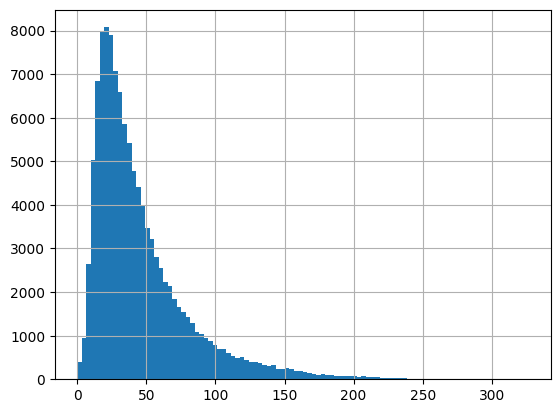

In [36]:
(df_eddies.Rc - df_eddies.R).abs().hist(bins=100)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


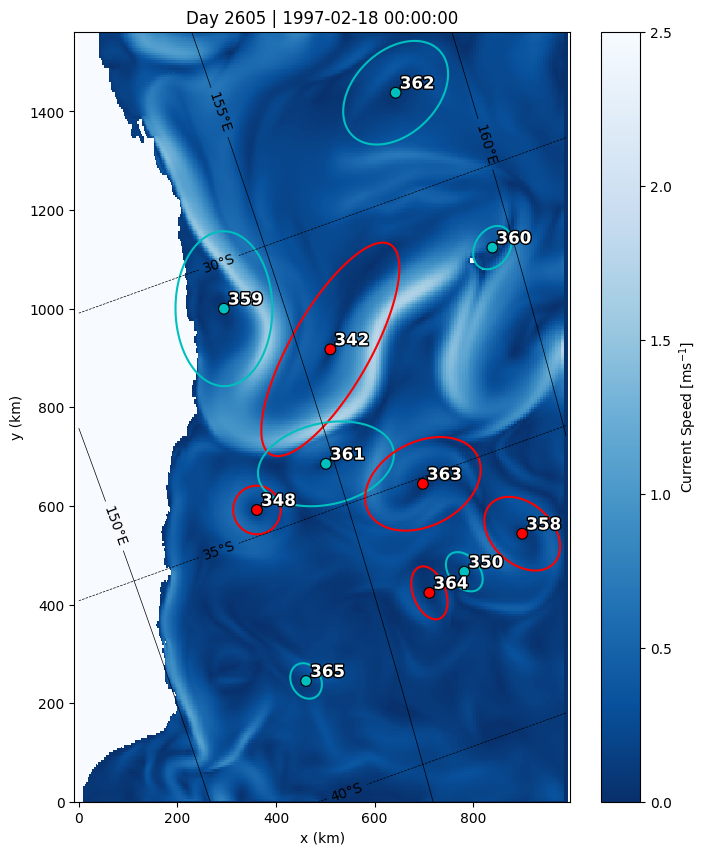

In [34]:
day_plot(2605, df_eddies)
